In [25]:
import pandas as pd

df = pd.read_csv('cars.csv')
df.head()


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


https://www.kaggle.com/datasets/tawfikelmetwally/automobile-dataset

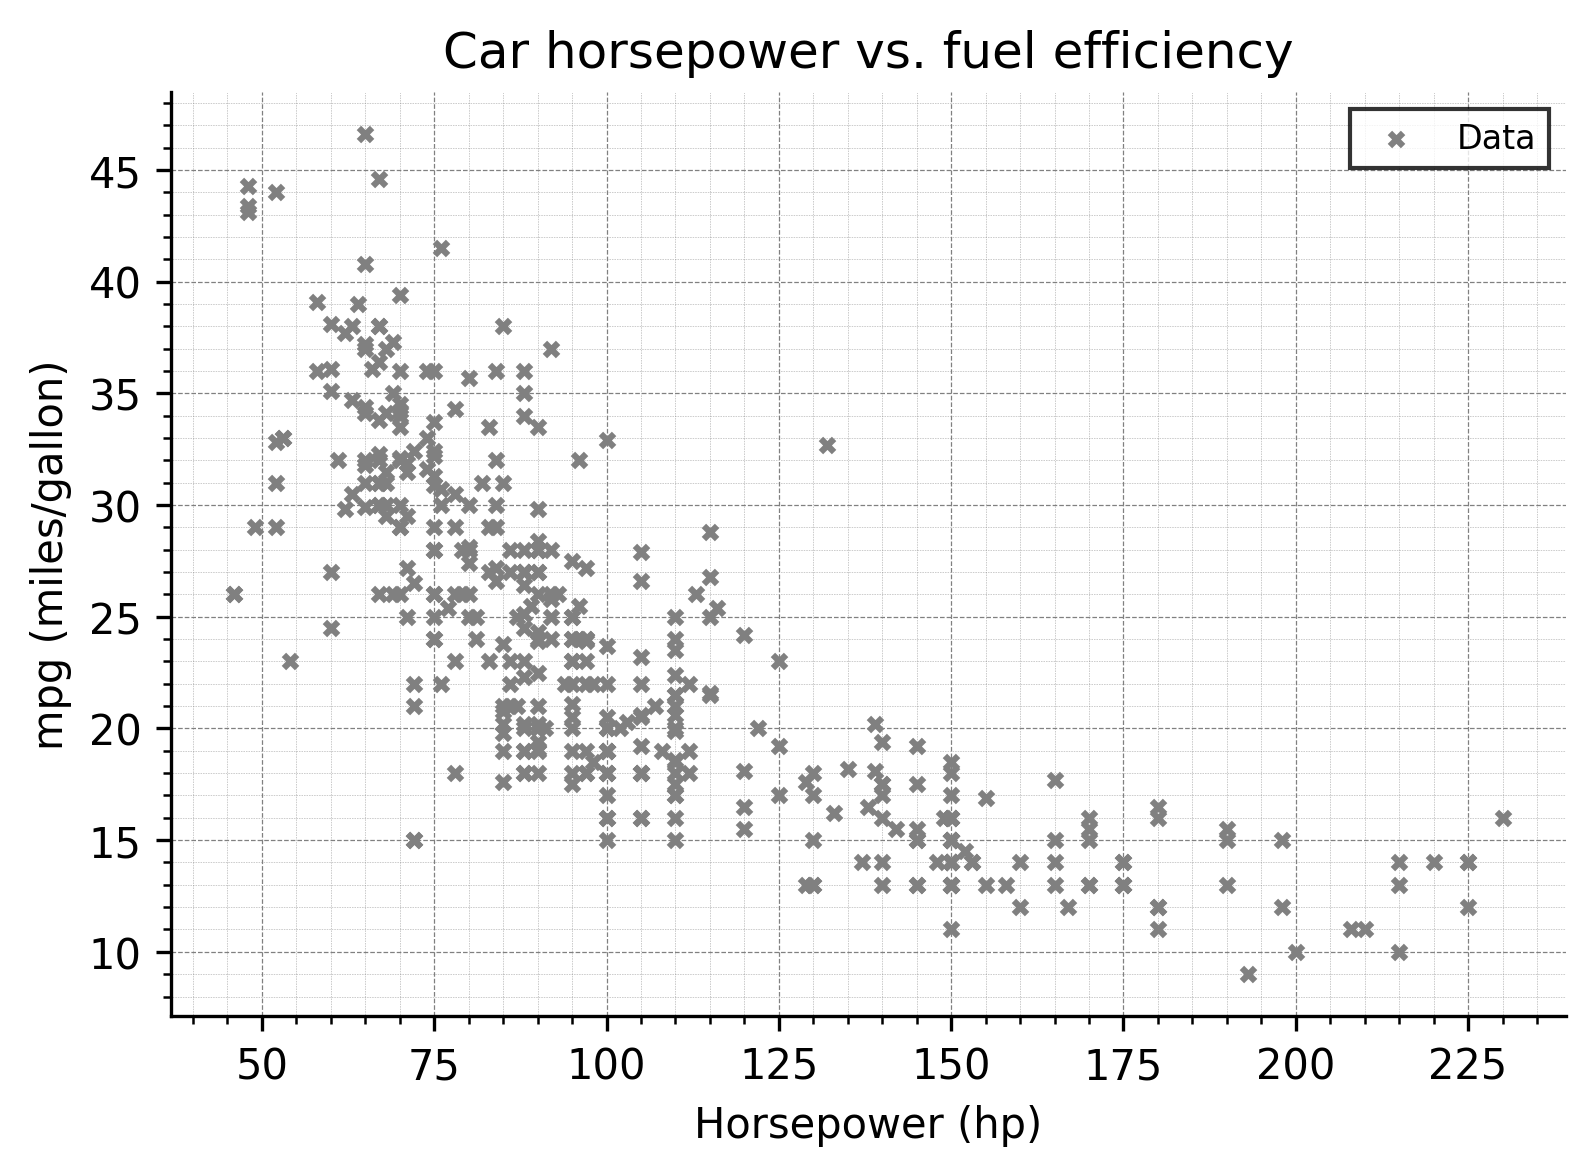

In [26]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 4), dpi=300)

# Major and Minor Ticks
plt.minorticks_on()

# Grid settings to mimic LaTeX style
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# Remove top and right spines to mimic LaTeX/pgfplots style
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=10)

plt.scatter(df['horsepower'], df['mpg'], label='Data', marker='x', color='grey', s=10)
plt.xlabel('Horsepower (hp)')
plt.ylabel('mpg (miles/gallon)')
plt.title('Car horsepower vs. fuel efficiency')

# legend
plt.legend(fontsize=8, edgecolor='black', facecolor='white', framealpha=0.8, fancybox=False)

plt.show()

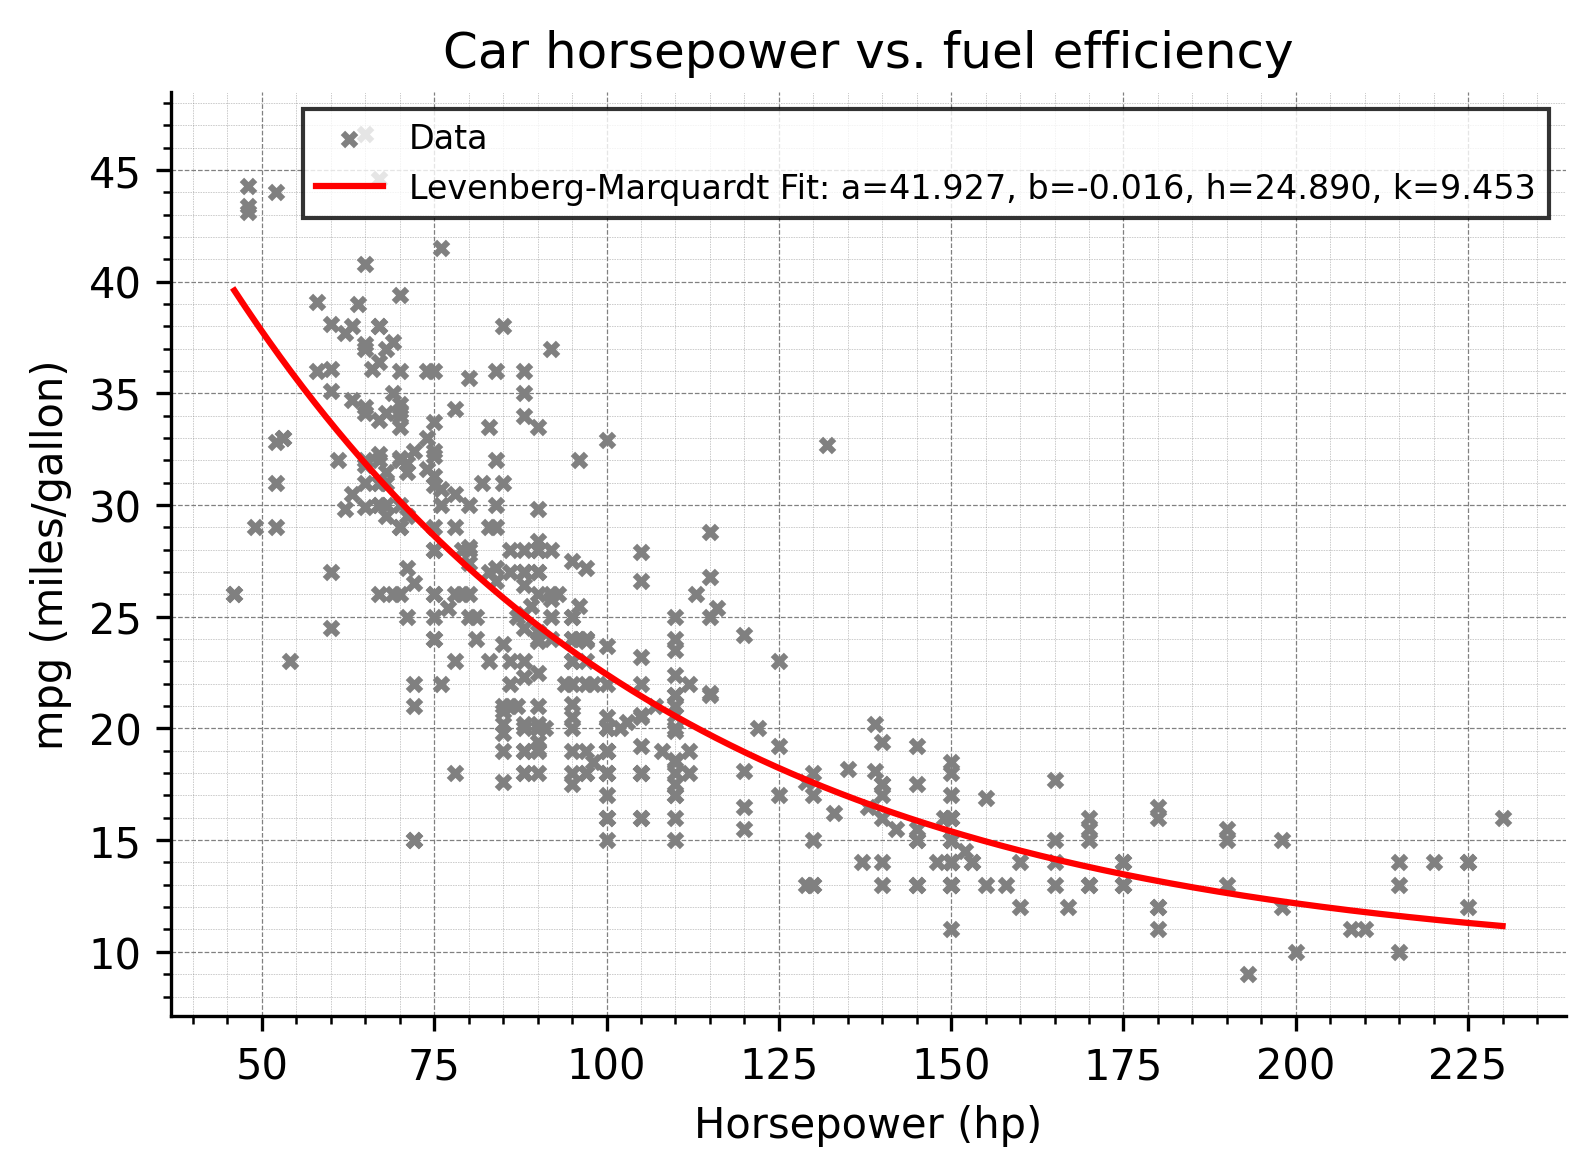

In [27]:
from scipy.optimize import curve_fit

# Define the exponential function to fit
def exp(x, a, b, h, k):
    return a * np.e**(b * (x - h)) + k

# Initial parameter guess
p0 = [5, -0.05, 90, 12]

# check for non-finite values (NaN, Inf) in the dataset
non_finite_values = df[['horsepower', 'mpg']].isnull().values.any()

# if non-finite values are found, we will clean the dataset
if non_finite_values:
    # remove rows with non-finite values
    df_clean = df.dropna(subset=['horsepower', 'mpg'])
else:
    # if there are no non-finite values, we will proceed with the current dataset
    df_clean = df

# try the curve fit without bounds on the cleaned data
popt, pcov = curve_fit(exp, df_clean['horsepower'], df_clean['mpg'], p0=p0)

# check if the covariance matrix was estimated successfully
if np.any(np.isinf(np.sqrt(np.diag(pcov)))):
    # if the unbounded fit also failed, we will try fitting with bounds and cleaned data.
    
    # define bounds within reasonable ranges based on the data
    bounds = ([0, -np.inf, df_clean['horsepower'].min(), 0], 
              [np.inf, 0, df_clean['horsepower'].max(), np.inf])
    
    # try the curve fit with bounds on the cleaned data
    popt_bound, pcov_bound = curve_fit(exp, df_clean['horsepower'], df_clean['mpg'], p0=p0, bounds=bounds)
    
    # check if this fit was successful
    if np.any(np.isinf(np.sqrt(np.diag(pcov_bound)))):
        # if the bounded fit also failed, we may need to try a different model or transformation.
        fit_success = False
    else:
        fit_success = True
        popt = popt_bound
        pcov = pcov_bound
else:
    # if the unbounded fit was successful, we will use these parameters.
    fit_success = True

# output the result of the fitting process
fit_success, popt, pcov

# create a high-resolution array of x values for a smooth curve
x_high_res = np.linspace(df_clean['horsepower'].min(), df_clean['horsepower'].max(), 1000)
# calculate the fitted y values using the high-resolution x values
y_fitted = exp(x_high_res, *popt)

# plot the original data and the fitted curve
plt.figure(figsize=(6, 4), dpi=300)
ax = plt.gca()

# gridlines/ticks
plt.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(df_clean['horsepower'], df_clean['mpg'], label='Data', marker='x', color='grey', s=10)
plt.plot(x_high_res, y_fitted, 'r-', label='Levenberg-Marquardt Fit: a=%5.3f, b=%5.3f, h=%5.3f, k=%5.3f' % tuple(popt))

plt.xlabel('Horsepower (hp)')
plt.ylabel('mpg (miles/gallon)')
plt.title('Car horsepower vs. fuel efficiency')

plt.legend(fontsize=8, edgecolor='black', facecolor='white', framealpha=0.8, fancybox=False)

plt.show()

In [28]:
from tqdm import tqdm

def gradient_descent(x, y, p0, learning_rate, num_iterations, max_step=0.1):
    # Initialize parameters
    a, b, h, k = p0
    
    # Store the parameter updates
    param_evolution = []
    loss_evolution = []
    
    # Exponential model function
    def model(x, a, b, h, k):
        return a * np.exp(b * (x - h)) + k
    
    # Loss function: sum of squared residuals
    def loss(y, y_pred):
        return np.sum((y - y_pred) ** 2)
    
    # Begin iterations
    for iteration in tqdm(range(num_iterations)):
        # Predicted y values from the current parameter set
        y_pred = model(x, a, b, h, k)
        
        # Calculate the loss
        current_loss = loss(y, y_pred)
        
        # Calculate the gradients for each parameter
        grad_a = -2 * np.sum((y - y_pred) * np.exp(b * (x - h)))
        grad_b = -2 * np.sum((y - y_pred) * a * (x - h) * np.exp(b * (x - h)))
        grad_h = 2 * np.sum((y - y_pred) * a * b * np.exp(b * (x - h)))
        grad_k = -2 * np.sum(y - y_pred)
        
        # Update step for each parameter
        step_a = learning_rate * grad_a
        step_b = learning_rate * grad_b
        step_h = learning_rate * grad_h
        step_k = learning_rate * grad_k

        # Apply the maximum step constraint
        step_a = np.clip(step_a, -max_step, max_step)
        step_b = np.clip(step_b, -max_step, max_step)
        step_h = np.clip(step_h, -max_step, max_step)
        step_k = np.clip(step_k, -max_step, max_step)

        # Update parameters
        a -= step_a
        b -= step_b
        h -= step_h
        k -= step_k
        
        # Save parameters for visualization
        param_evolution.append((a, b, h, k))
        loss_evolution.append(current_loss)
        
        # Print the iteration, loss, and parameters
        # print(f"Iteration {iteration+1}: Loss={current_loss:.4f}, a={a:.4f}, b={b:.4f}, h={h:.4f}, k={k:.4f}")
        
        # Break if the loss is not finite (indicates divergence)
        if not np.isfinite(current_loss):
            print("Gradient descent is diverging. Stopping early.")
            break
        
    return param_evolution, loss_evolution

# Parameters for the gradient descent
initial_params = [50, -0.001, 1, 1]
learning_rate = 1e-9 # Smaller learning rate to prevent overshooting
num_iterations = 50000 # Number of iterations

# Run the gradient descent optimization with new learning rate and step size cap
print("Running gradient descent...")
param_evolution, loss_evolution = gradient_descent(df_clean['horsepower'], df_clean['mpg'], initial_params, learning_rate, num_iterations, max_step=1)

# Plot for the fitting
# Select iterations to visualize the optimization process
visualize_iterations = list(range(0, (num_iterations + 1), 10000))

# Plot the data
plt.figure(figsize=(6, 4), dpi=300)
ax = plt.gca()

# gridlines/ticks
plt.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(df_clean['horsepower'], df_clean['mpg'], label='Data', marker='x', color='grey', s=10)

# Plot the model fit at selected iterations
for i in visualize_iterations:
    # Get the parameters from the ith iteration
    index = 0 if i == 0 else i - 1
    a, b, h, k = param_evolution[index]
    
    print(f"REPORT: Iteration {i}: a={a:.4f}, b={b:.4f}, h={h:.4f}, k={k:.4f}, Loss={loss_evolution[index]:.4f}")
    
    # Generate the model predictions
    x_values = np.linspace(df_clean['horsepower'].min(), df_clean['horsepower'].max(), 500)
    y_values = a * np.exp(b * (x_values - h)) + k
    
    # Plot
    plt.plot(x_values, y_values, label=f'Iteration {i}', linewidth=0.5)

plt.xlabel('Horsepower (hp)')
plt.ylabel('mpg (miles/gallon)')
plt.title('Gradient Descent Optimization of Model Fit')
plt.legend(fontsize=8)
plt.show()

# Plot the evolution of the loss with smoothing
from scipy.ndimage import gaussian_filter1d
smoothed_loss = gaussian_filter1d(loss_evolution, sigma=50)

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(smoothed_loss, linewidth=0.5)
plt.ylim(20000, 80000)
plt.title('Evolution of Loss (Smoothed)')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)

ax = plt.gca()

# gridlines/ticks
plt.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

Running gradient descent...


  0%|          | 161/50000 [00:00<00:36, 1362.99it/s]


KeyboardInterrupt: 

Running gradient descent...


100%|██████████| 50000/50000 [00:35<00:00, 1402.58it/s]


Running simulated annealing...


  1%|          | 287/50000 [00:00<00:17, 2861.45it/s]/opt/homebrew/Caskroom/miniconda/base/envs/jupyter/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
  2%|▏         | 1145/50000 [00:00<00:17, 2848.27it/s]/var/folders/ht/7rs593hn3kl_sc6g4gdhk3v40000gn/T/ipykernel_37642/1886680217.py:74: RuntimeWarning: overflow encountered in scalar divide
  if delta_loss < 0 or np.random.rand() < np.exp(-delta_loss / T):
100%|██████████| 50000/50000 [00:17<00:00, 2829.60it/s]


[0, 9999, 19999, 29999, 39999, 49999]


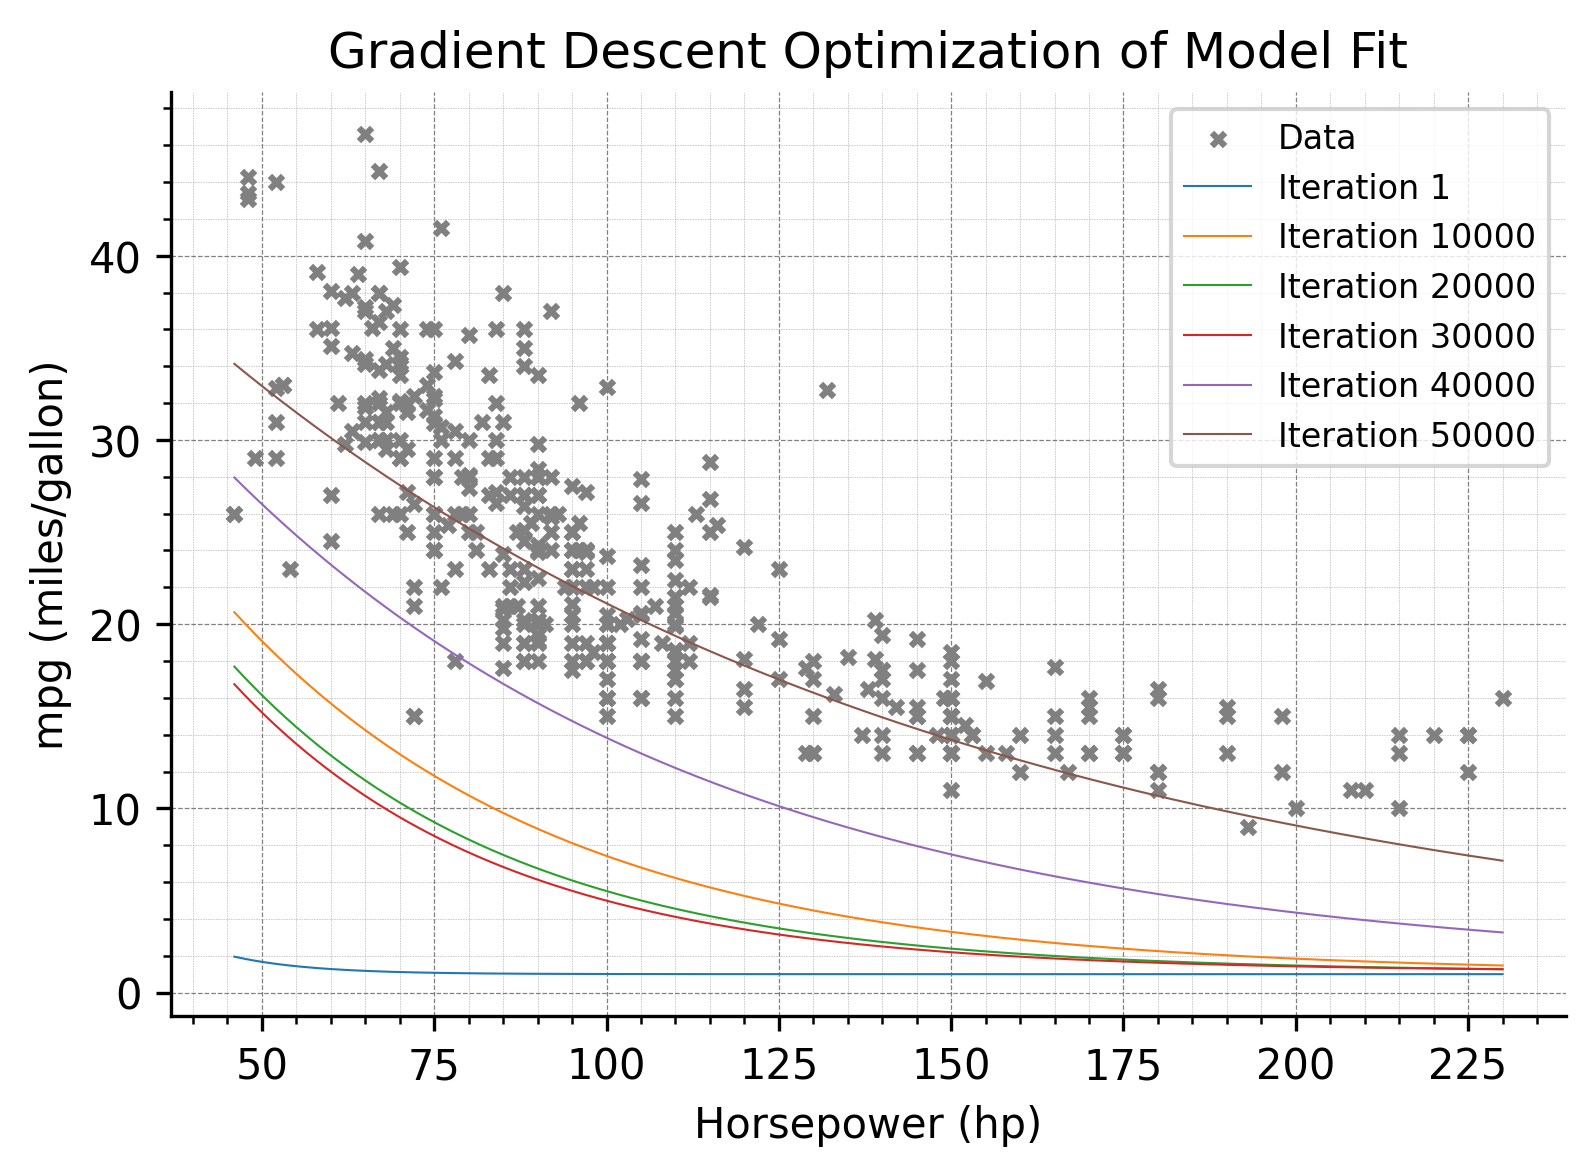

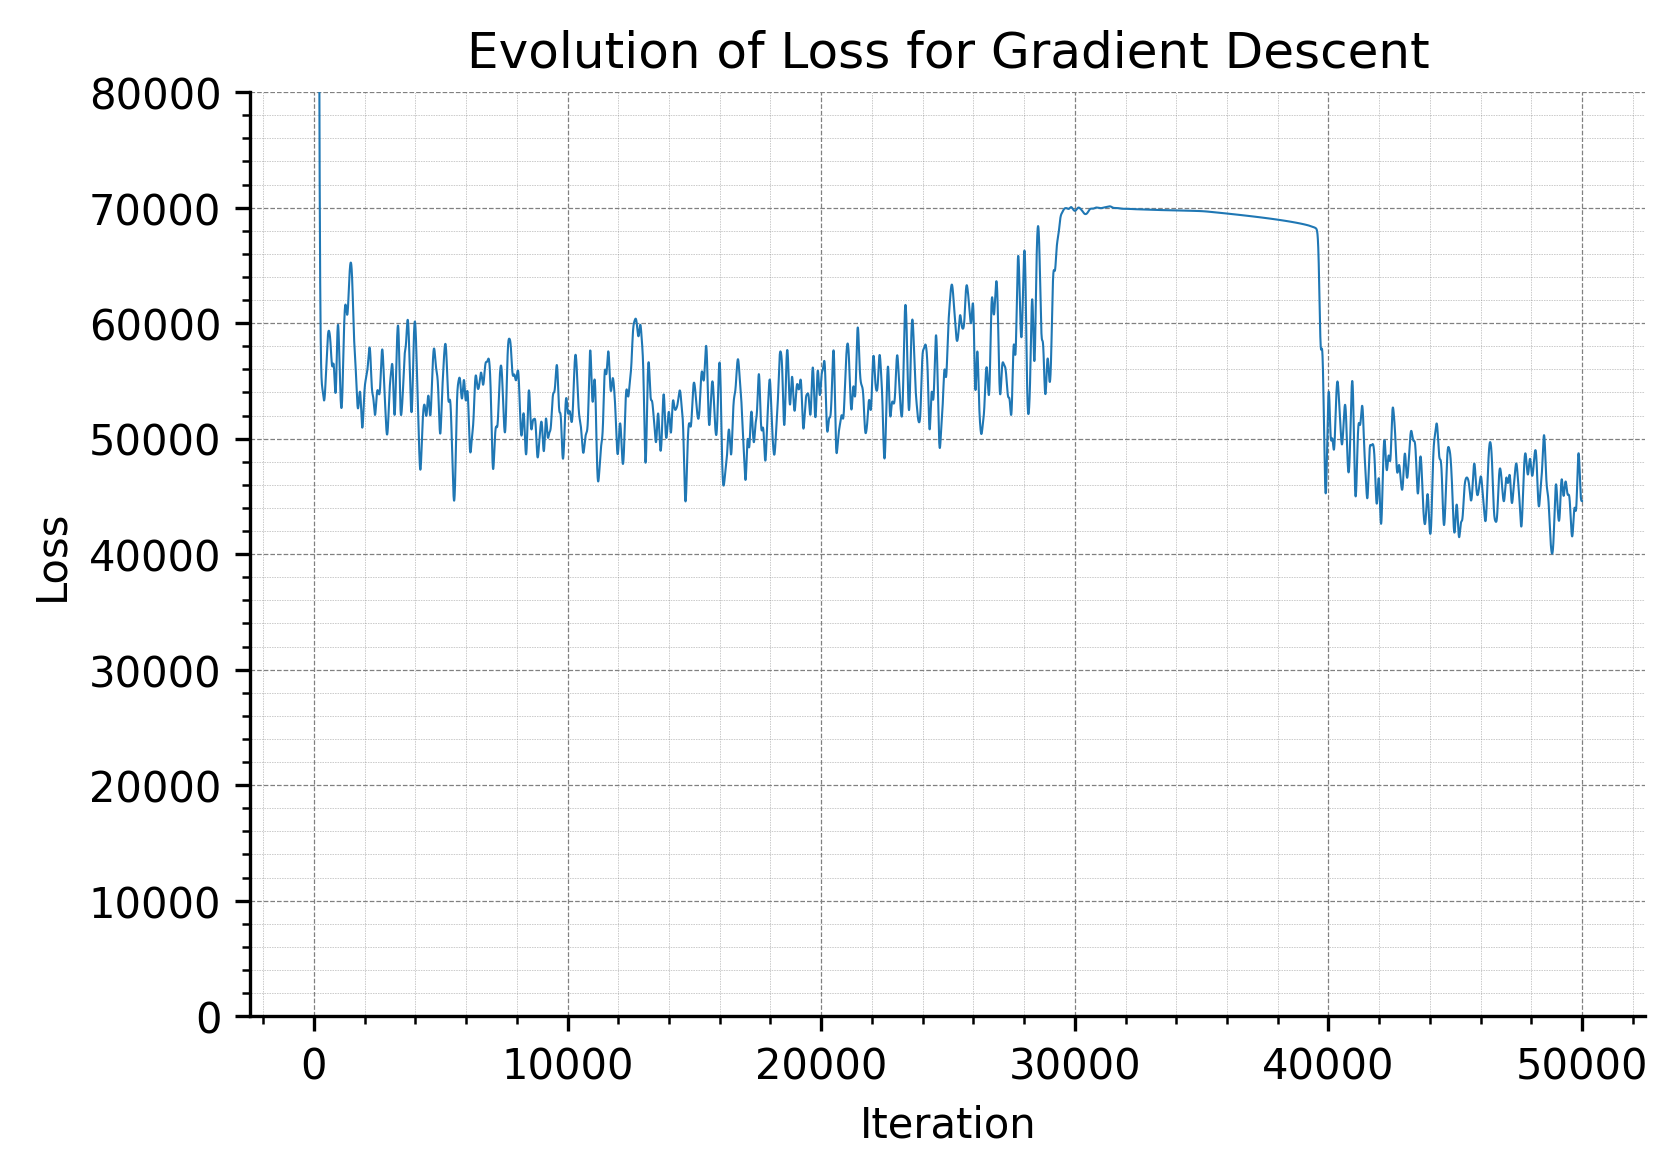

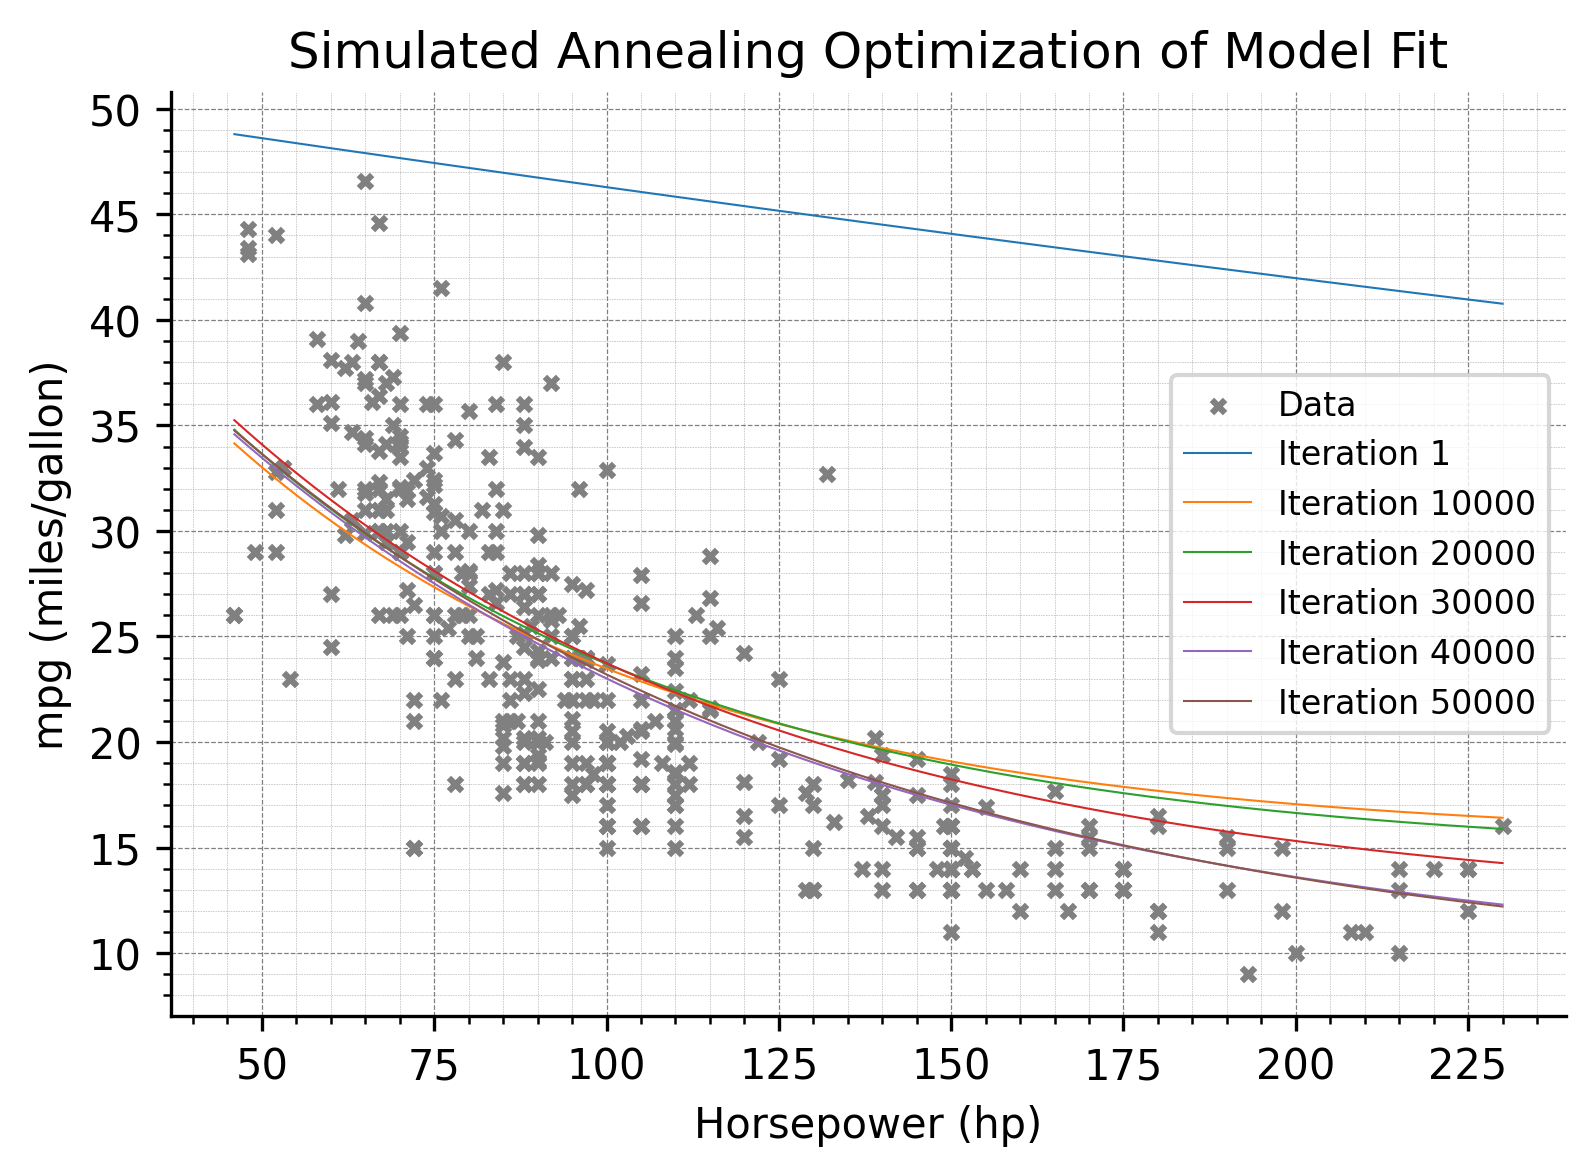

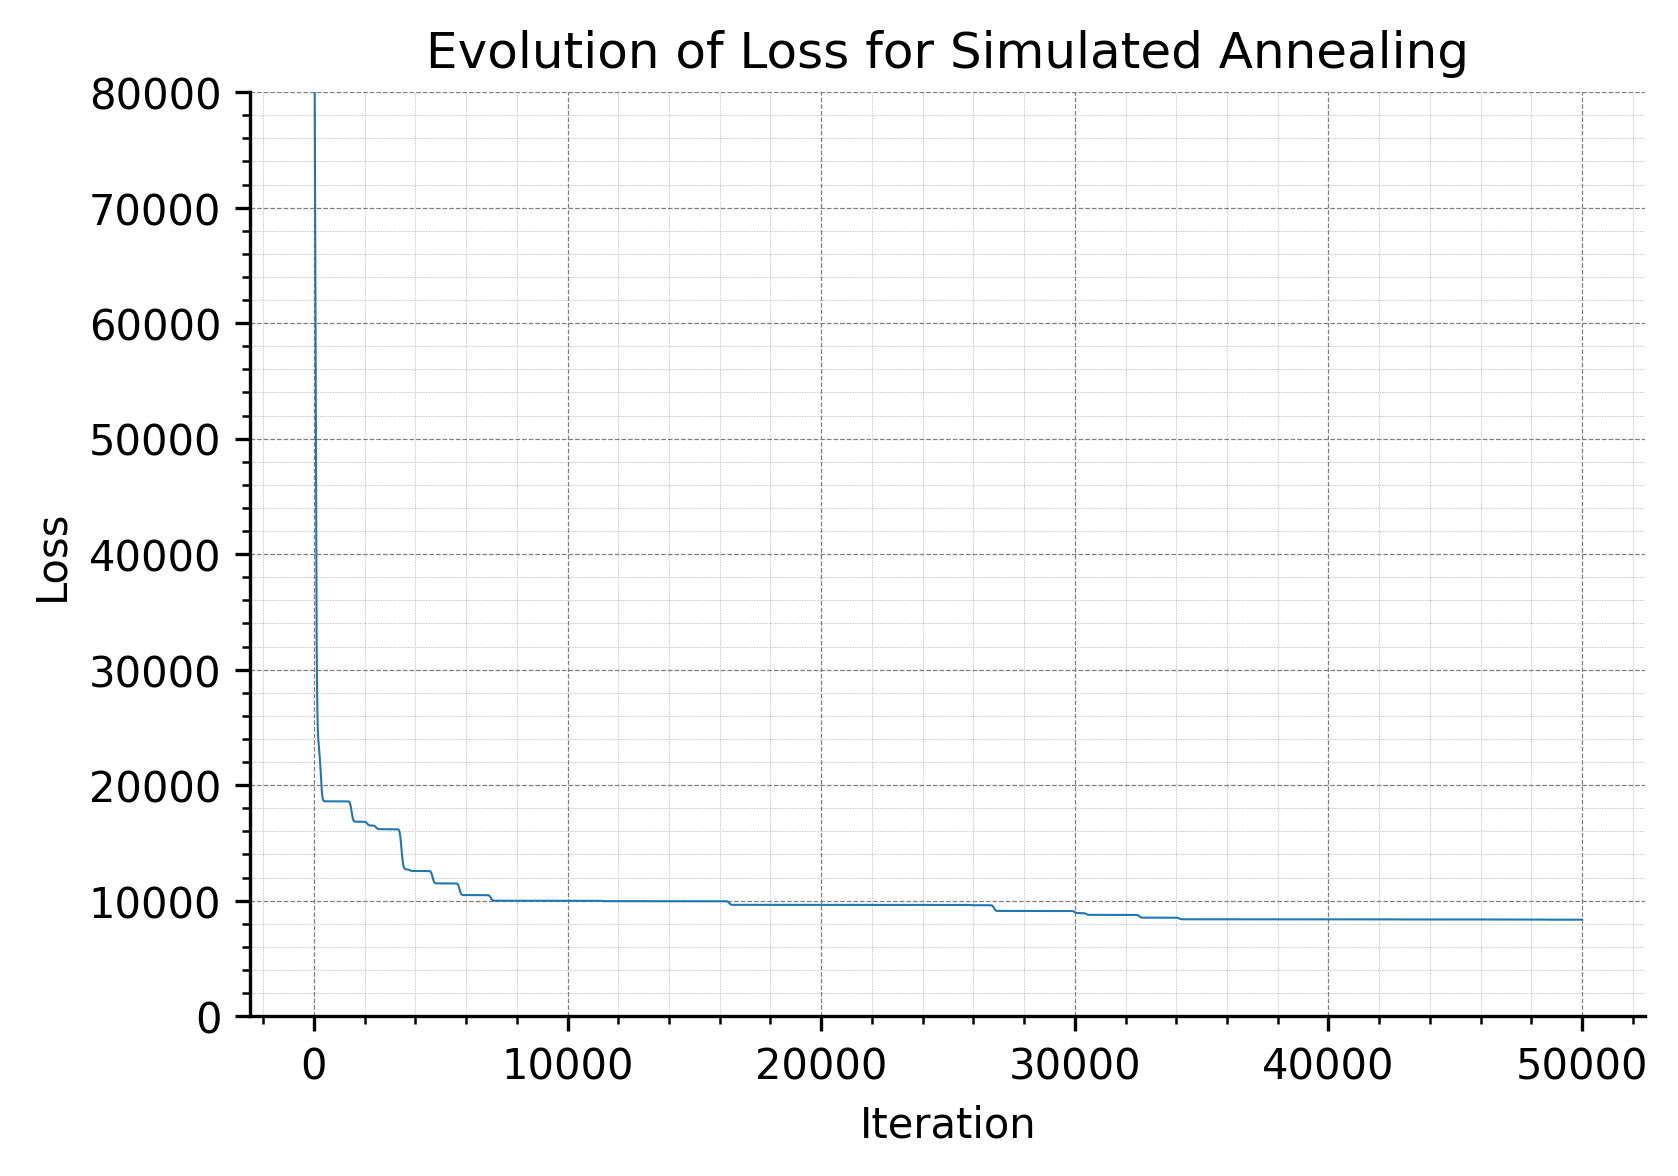

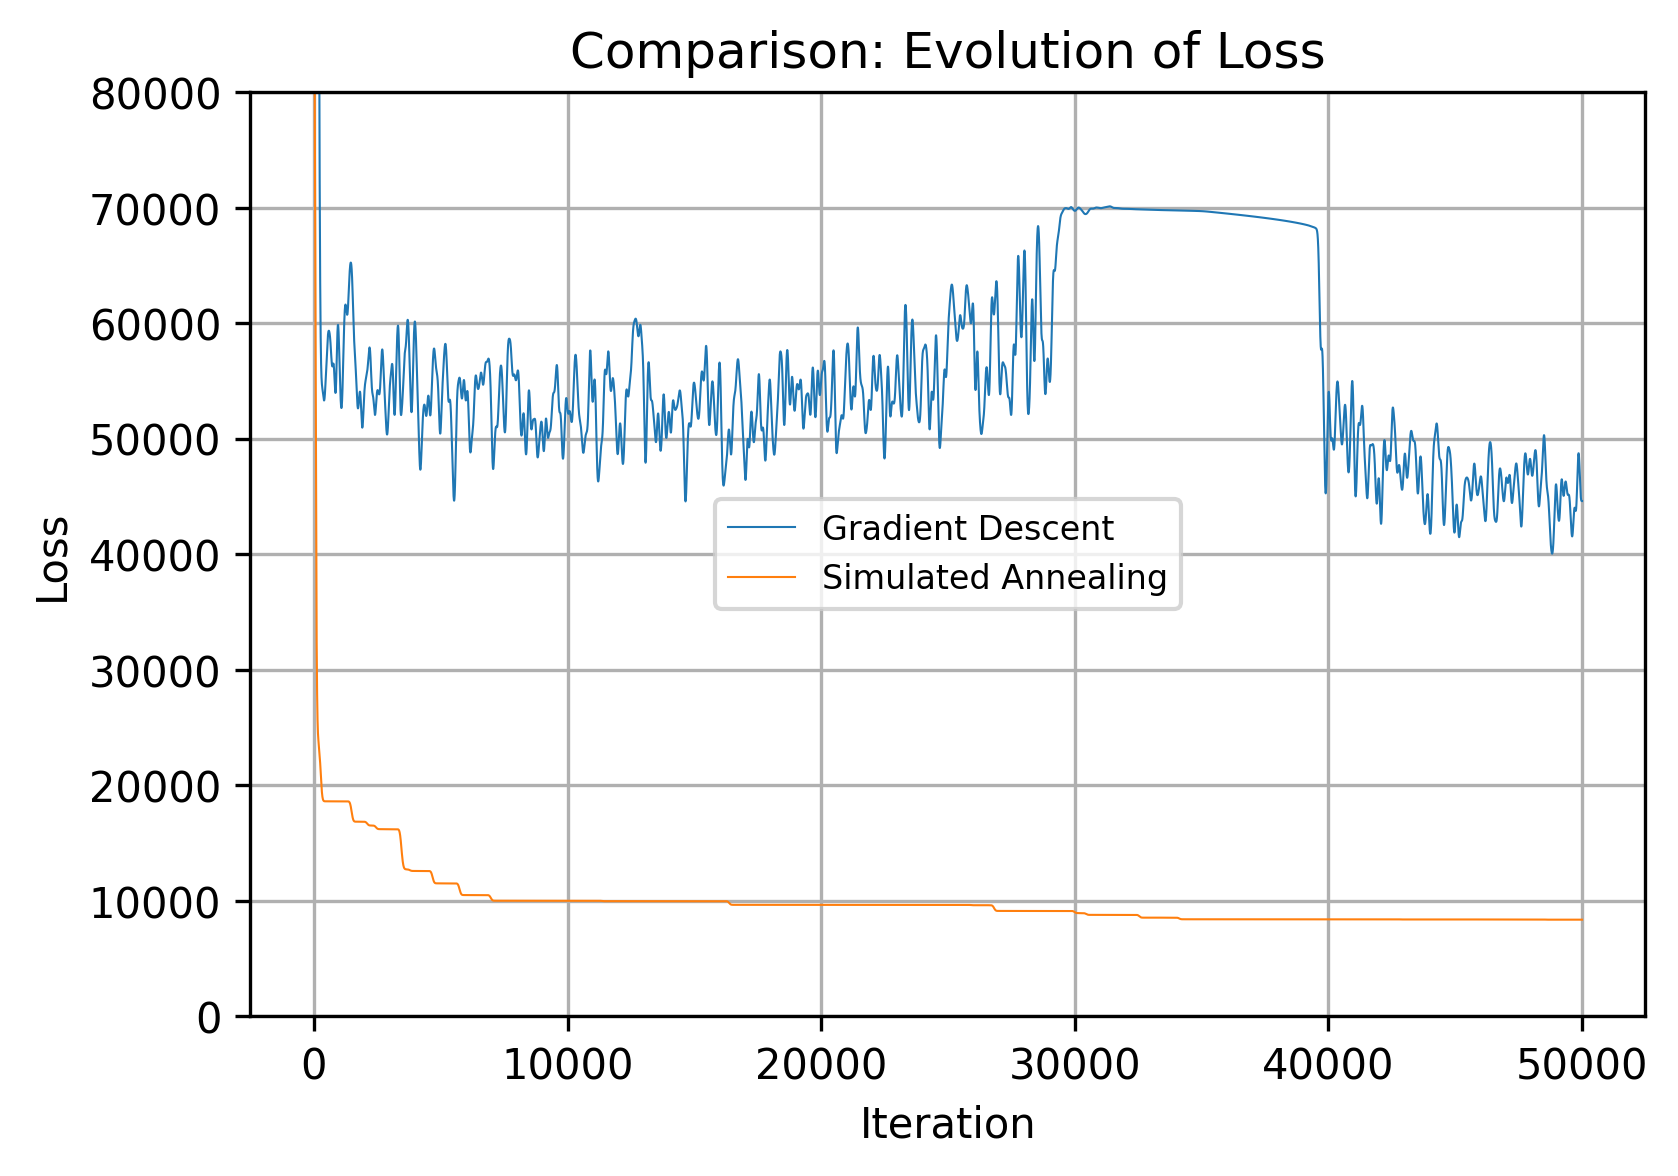

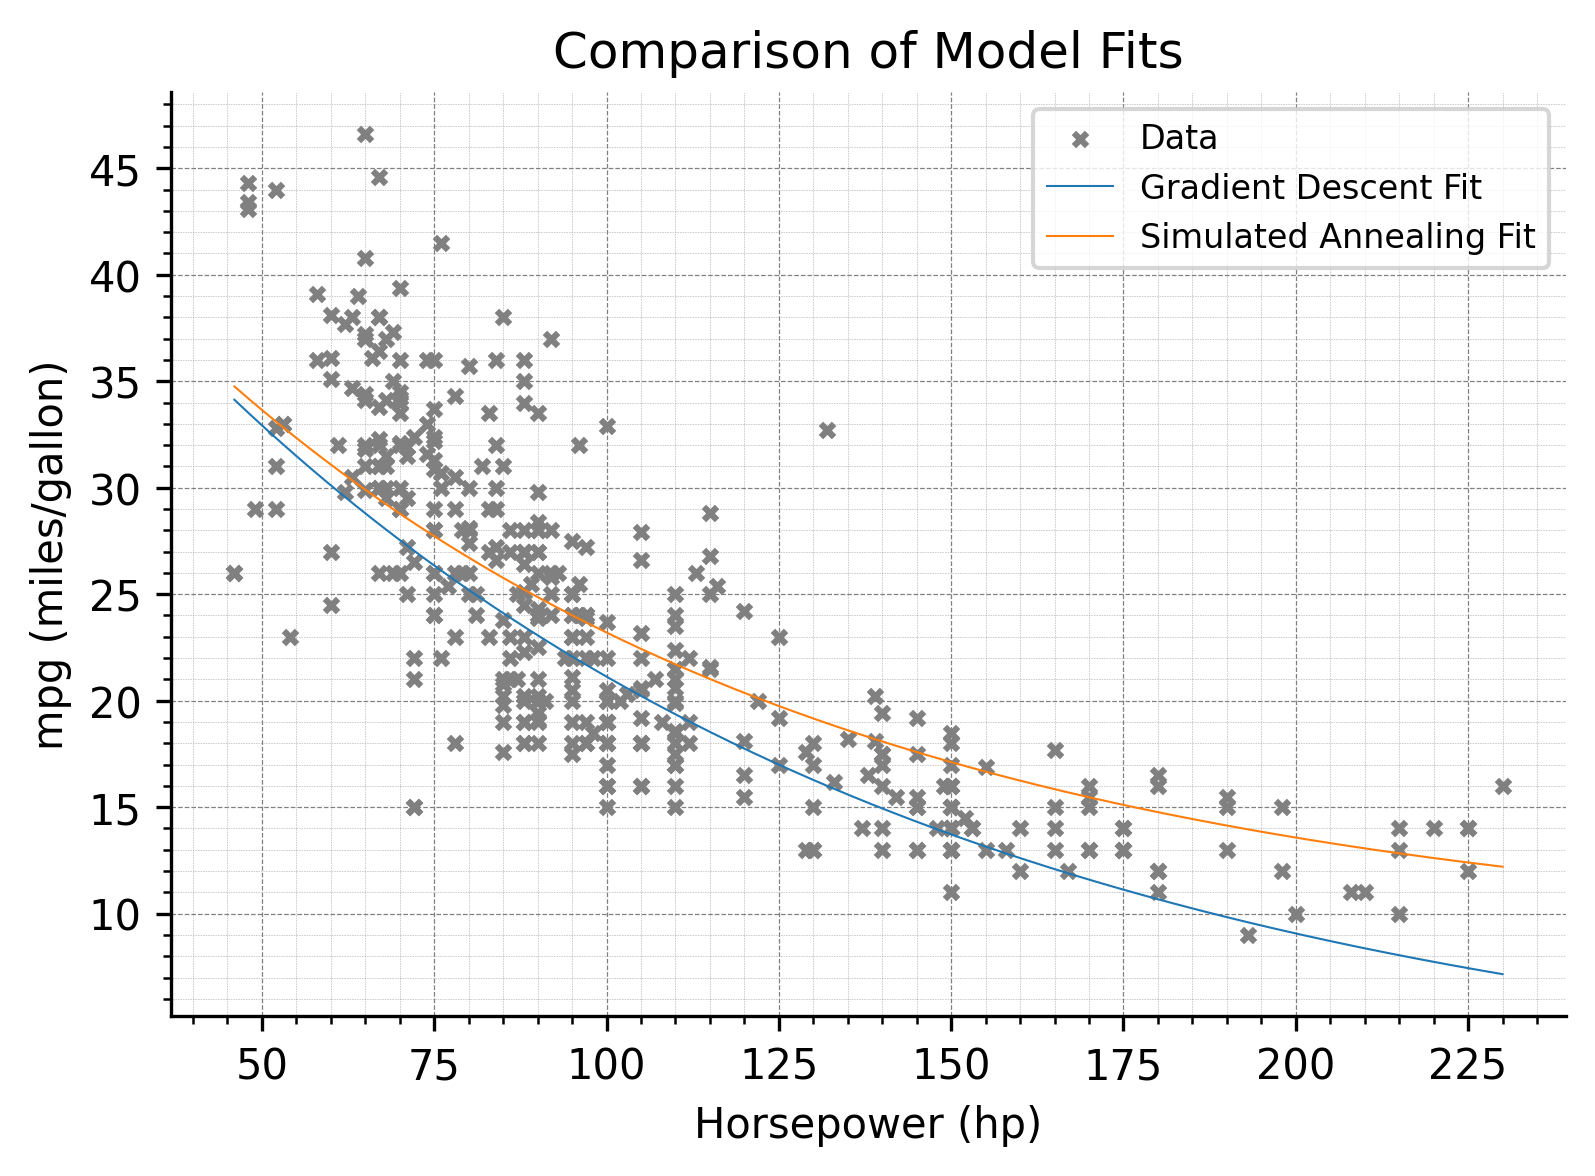

,Iteration,Algorithm,a,b,h,k,Loss
0,0,GD,49.999984,-0.088050,0.999999,0.999982,218298.481099
1,0,SA,50.000000,-0.001000,1.000000,1.000000,218298.481099
2,9999,GD,50.002055,-0.020810,1.007488,1.045211,135072.588923
3,9999,SA,43.122749,-0.015491,-7.504605,15.322251,9995.768628
4,19999,GD,50.004091,-0.024499,1.014831,1.087049,35210.628367
5,19999,SA,44.548638,-0.014657,-7.687601,14.514481,9638.343247
6,29999,GD,50.006242,-0.025888,1.022801,1.133115,38596.411583
7,29999,SA,45.046446,-0.012661,-6.246742,12.000119,8923.295945
8,39999,GD,50.008672,-0.013894,1.032289,1.189655,13423.978326
9,39999,SA,44.205690,-0.011160,-3.069155,9.015017,8388.956892


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import dual_annealing
from tqdm import tqdm

# Exponential model function
def model(x, a, b, h, k):
    return a * np.exp(b * (x - h)) + k

# Loss function: sum of squared residuals
def loss(y, y_pred):
    return np.sum((y - y_pred) ** 2)

# Optimization function that takes another function as the optimization algorithm
def optimize(x, y, initial_params, num_iterations, optimizer_func, *args, **kwargs):
    param_evolution = []
    loss_evolution = []
    
    params = initial_params
    T = kwargs.pop('T0', None)
    alpha = kwargs.pop('alpha', None)
    
    for iteration in tqdm(range(num_iterations)):
        if optimizer_func.__name__ == "simulated_annealing_optimizer":
            params, current_loss, T = optimizer_func(x, y, params, iteration, T, alpha)
        else:
            params, current_loss = optimizer_func(x, y, params, iteration, *args, **kwargs)
        
        param_evolution.append(params)
        loss_evolution.append(current_loss)
        
        if not np.isfinite(current_loss):
            print("Optimization is diverging. Stopping early.")
            break
        
    return param_evolution, loss_evolution

# Gradient Descent optimizer function
def gradient_descent_optimizer(x, y, params, iteration, learning_rate, max_step):
    a, b, h, k = params
    y_pred = model(x, a, b, h, k)
    current_loss = loss(y, y_pred)
    
    # Calculate gradients
    grad_a = -2 * np.sum((y - y_pred) * np.exp(b * (x - h)))
    grad_b = -2 * np.sum((y - y_pred) * a * (x - h) * np.exp(b * (x - h)))
    grad_h = 2 * np.sum((y - y_pred) * a * b * np.exp(b * (x - h)))
    grad_k = -2 * np.sum(y - y_pred)
    
    # Update parameters
    a -= np.clip(learning_rate * grad_a, -max_step, max_step)
    b -= np.clip(learning_rate * grad_b, -max_step, max_step)
    h -= np.clip(learning_rate * grad_h, -max_step, max_step)
    k -= np.clip(learning_rate * grad_k, -max_step, max_step)
    
    return (a, b, h, k), current_loss

# Simulated Annealing optimizer function
def simulated_annealing_optimizer(x, y, params, iteration, T, alpha):
    # result = dual_annealing(objective_function, bounds, maxiter=1, initial_temp=5230, restart_temp_ratio=2e-5, visit=2.62, accept=-5.0, no_local_search=True, x0=params)
    
    # Perturb the current solution
    new_params = params + np.random.normal(0, 1, size=len(params))
    
    # Calculate loss for the current and new solutions
    current_loss = loss(y, model(x, *params))
    new_loss = loss(y, model(x, *new_params))
    
    # Calculate the change in loss
    delta_loss = new_loss - current_loss
    
    # Decide whether to accept the new solution
    if delta_loss < 0 or np.random.rand() < np.exp(-delta_loss / T):
        params = new_params  # Accept new solution
        current_loss = new_loss
    
    # Cooling step (decrease temperature)
    T *= alpha
    
    return params, current_loss, T

# Parameters for the optimization
initial_params = [50, -0.001, 1, 1]

gd_iterations = 50000
gd_learning_rate = 1e-9
gd_max_step = 1

sa_iterations = 50000
sa_T0 = 500  # Initial temperature
sa_alpha = 0.98  # Cooling factor

# Run Gradient Descent optimization
print("Running gradient descent...")
gd_param_evolution, gd_loss_evolution = optimize(
    df_clean['horsepower'], df_clean['mpg'], initial_params, gd_iterations,
    gradient_descent_optimizer, learning_rate=gd_learning_rate, max_step=gd_max_step
)

# Run Simulated Annealing optimization
print("Running simulated annealing...")
sa_param_evolution, sa_loss_evolution = optimize(
    df_clean['horsepower'], df_clean['mpg'], initial_params, sa_iterations,
    simulated_annealing_optimizer, T0=sa_T0, alpha=sa_alpha
)

# Function to plot optimization progress
def plot_optimization(x, y, param_evolution, loss_evolution, title, loss_title, visualize_iterations):
    # Plot for the fitting
    plt.figure(figsize=(6, 4), dpi=300)
    ax = plt.gca()

    # gridlines/ticks
    plt.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=10)
    plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
    plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

    # remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.scatter(x, y, label='Data', marker='x', color='grey', s=10)

    # Plot the model fit at selected iterations
    for i in visualize_iterations:
        # Get the parameters from the ith iteration
        a, b, h, k = param_evolution[i]
        
        # Generate the model predictions
        x_values = np.linspace(x.min(), x.max(), 500)
        y_values = model(x_values, a, b, h, k)
        
        # Plot
        plt.plot(x_values, y_values, label=f'Iteration {i+1}', linewidth=0.5)

    plt.xlabel('Horsepower (hp)')
    plt.ylabel('mpg (miles/gallon)')
    plt.title(title)
    plt.legend(fontsize=8)
    plt.show()

    # Plot the evolution of the loss with smoothing
    smoothed_loss = gaussian_filter1d(loss_evolution, sigma=50)

    plt.figure(figsize=(6, 4), dpi=300)
    plt.plot(smoothed_loss, linewidth=0.5)
    plt.ylim(0, 80000)
    plt.title(loss_title)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.grid(True)

    ax = plt.gca()

    # gridlines/ticks
    plt.minorticks_on()
    ax.tick_params(axis='both', which='major', labelsize=10)
    plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
    plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

    # remove top/right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()

# Function to plot the evolution of loss for both optimization algorithms
def plot_loss_evolution(gd_loss_evolution, sa_loss_evolution, title):
    # Plot Gradient Descent loss evolution
    plt.figure(figsize=(6, 4), dpi=300)
    smoothed_loss_gd = gaussian_filter1d(gd_loss_evolution, sigma=50)
    plt.plot(smoothed_loss_gd, label='Gradient Descent', linewidth=0.5)
    
    # Plot Simulated Annealing loss evolution
    smoothed_loss_sa = gaussian_filter1d(sa_loss_evolution, sigma=50)
    plt.plot(smoothed_loss_sa, label='Simulated Annealing', linewidth=0.5)
    
    plt.ylim(0, 80000)
    plt.title(title)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

# Plot the results for Gradient Descent
gd_selected_iterations = [0] + list(range(9999, gd_iterations+1, 10000))
print(gd_selected_iterations)
plot_optimization(df_clean['horsepower'], df_clean['mpg'], gd_param_evolution, gd_loss_evolution, 'Gradient Descent Optimization of Model Fit', 'Evolution of Loss for Gradient Descent', gd_selected_iterations)

# Plot the results for Simulated Annealing
sa_selected_iterations = [0] + list(range(9999, sa_iterations+1, 10000))
plot_optimization(df_clean['horsepower'], df_clean['mpg'], sa_param_evolution, sa_loss_evolution, 'Simulated Annealing Optimization of Model Fit', 'Evolution of Loss for Simulated Annealing', sa_selected_iterations)

# compare loss between both
plot_loss_evolution(gd_loss_evolution, sa_loss_evolution, 'Comparison: Evolution of Loss')

# Plot of the two fits on the same scatter plot
plt.figure(figsize=(6, 4), dpi=300)
ax = plt.gca()

# gridlines/ticks
plt.minorticks_on()
ax.tick_params(axis='both', which='major', labelsize=10)
plt.grid(which='both', linestyle='--', linewidth='0.30', color='gray')
plt.grid(which='minor', linestyle=':', linewidth='0.15', color='gray')

# remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.scatter(df_clean['horsepower'], df_clean['mpg'], label='Data', marker='x', color='grey', s=10)

# Gradient Descent final fit
gd_final_params = gd_param_evolution[-1]
x_values = np.linspace(df_clean['horsepower'].min(), df_clean['horsepower'].max(), 500)
gd_y_values = model(x_values, *gd_final_params)
plt.plot(x_values, gd_y_values, label='Gradient Descent Fit', linewidth=0.5)

# Simulated Annealing final fit
sa_final_params = sa_param_evolution[-1]
sa_y_values = model(x_values, *sa_final_params)
plt.plot(x_values, sa_y_values, label='Simulated Annealing Fit', linewidth=0.5)

plt.xlabel('Horsepower (hp)')
plt.ylabel('mpg (miles/gallon)')
plt.title('Comparison of Model Fits')
plt.legend(fontsize=8)
plt.show()

def report(gd_report_iterations, sa_report_iterations):
    gd_report_data = {
    'Iteration': gd_report_iterations,
    'Algorithm': 'GD',
    'a': [gd_param_evolution[i][0] if i < len(gd_param_evolution) else None for i in gd_report_iterations],
    'b': [gd_param_evolution[i][1] if i < len(gd_param_evolution) else None for i in gd_report_iterations],
    'h': [gd_param_evolution[i][2] if i < len(gd_param_evolution) else None for i in gd_report_iterations],
    'k': [gd_param_evolution[i][3] if i < len(gd_param_evolution) else None for i in gd_report_iterations],
    'Loss': [gd_loss_evolution[i] if i < len(gd_loss_evolution) else None for i in gd_report_iterations]
    }

    sa_report_data = {
        'Iteration': sa_report_iterations,
        'Algorithm': 'SA',
        'a': [sa_param_evolution[i][0] if i < len(sa_param_evolution) else None for i in sa_report_iterations],
        'b': [sa_param_evolution[i][1] if i < len(sa_param_evolution) else None for i in sa_report_iterations],
        'h': [sa_param_evolution[i][2] if i < len(sa_param_evolution) else None for i in sa_report_iterations],
        'k': [sa_param_evolution[i][3] if i < len(sa_param_evolution) else None for i in sa_report_iterations],
        'Loss': [sa_loss_evolution[i] if i < len(sa_loss_evolution) else None for i in sa_report_iterations]
    }

    # Convert the dictionaries to DataFrames
    gd_report_df = pd.DataFrame(gd_report_data)
    sa_report_df = pd.DataFrame(sa_report_data)

    # Concatenate the Gradient Descent and Simulated Annealing report DataFrames
    report_df = pd.concat([gd_report_df, sa_report_df])

    # Sort by 'Iteration' and reset the index
    report_df.sort_values(by='Iteration', inplace=True)
    report_df.reset_index(drop=True, inplace=True)

    # Display the combined DataFrame
    report_df.sort_values(by='Iteration', inplace=True)
    report_df.reset_index(drop=True, inplace=True)
    report_df
    
    return report_df

report_df = report(gd_selected_iterations, sa_selected_iterations)
report_df